# Sesión 3 · Imputación y preparación de datos
## House Prices — Advanced Regression Techniques

| | |
|---|---|
| **Equipo** | Israel González Huerta A01751433<br>Luis David Pozos Tamez A01800657<br>Adrián Proaño Bernal A01752615<br>Juan Pablo Solís Gómez A01800430<br>Karol Alexis Alvarado Davila A01751711 |
| **Fecha** | 28 de agosto de 2026 |
| **Objetivo** | Construir el pipeline completo de preparación de datos: Manejo de datos faltantes, codificación, transformación y escalado. |

---

> Usamos el mismo `train.csv` que descargaron en la sesión 1. Si no lo tienen, revisen las instrucciones de descarga en el notebook de la sesión anterior o del `README.md`.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/train.csv')
print('Dataset cargado:', df.shape)


Dataset cargado: (1460, 81)


---
## Datos faltantes

Primer diagnóstico: ¿cuántos nulos hay y en qué columnas?

In [4]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(1)

resumen_nulos = pd.DataFrame({'n_nulos': nulos, 'pct': nulos_pct})
resumen_nulos = resumen_nulos[resumen_nulos['n_nulos'] > 0].sort_values('pct', ascending=False)

print('Columnas con faltantes:')
print(resumen_nulos)

Columnas con faltantes:
              n_nulos   pct
PoolQC           1453  99.5
MiscFeature      1406  96.3
Alley            1369  93.8
Fence            1179  80.8
MasVnrType        872  59.7
FireplaceQu       690  47.3
LotFrontage       259  17.7
GarageType         81   5.5
GarageYrBlt        81   5.5
GarageFinish       81   5.5
GarageQual         81   5.5
GarageCond         81   5.5
BsmtExposure       38   2.6
BsmtFinType2       38   2.6
BsmtQual           37   2.5
BsmtCond           37   2.5
BsmtFinType1       37   2.5
MasVnrArea          8   0.5
Electrical          1   0.1


> **Antes de imputar:** la pregunta es si cada nulo es un **faltante informativo** (NaN = categoría real) o un **faltante real** (dato que simplemente no se registró).

---
## Faltantes informativos

En House Prices, muchos NaN significan "la propiedad no tiene esa característica".

| Columna | NaN significa |
|---------|---------------|
| `PoolQC` | No tiene alberca |
| `GarageType` | No tiene garage |

Imputar con la mediana aquí sería **incorrecto**: le estaríamos asignando una calidad de alberca a casas que no tienen alberca.

In [5]:
# Columnas donde NaN = ausencia de la característica
informativos_cat = ['PoolQC', 'GarageType']

for col in informativos_cat:
    antes = df[col].isnull().sum()
    df[col] = df[col].fillna('None')
    despues = df[col].isnull().sum()
    print(f'{col}: {antes} nulos → {despues} nulos  |  nueva categoría "None" = sin {col}')

# Verificar que efectivamente 'None' es ahora la categoría más frecuente en PoolQC
print('\nDistribución PoolQC:')
print(df['PoolQC'].value_counts())

PoolQC: 1453 nulos → 0 nulos  |  nueva categoría "None" = sin PoolQC
GarageType: 81 nulos → 0 nulos  |  nueva categoría "None" = sin GarageType

Distribución PoolQC:
PoolQC
None    1453
Gd         3
Ex         2
Fa         2
Name: count, dtype: int64


---
## Corrección de tipo: `MSSubClass`

`MSSubClass` viene como número entero en el CSV, pero **no** es una variable numérica:
- `20` = 1-Story 1946+
- `60` = 2-Story 1946+
- `190` = 2 Family Conversion

Promediar `20` y `60` da `40`, que no corresponde a ningún tipo de edificio. Es una **etiqueta numérica**, no una magnitud.

In [6]:
print('Tipo ANTES:', df['MSSubClass'].dtype)
print('Valores únicos:', sorted(df['MSSubClass'].unique()))

df['MSSubClass'] = df['MSSubClass'].astype(str)

print('\nTipo DESPUÉS:', df['MSSubClass'].dtype)
print('Valores únicos:', sorted(df['MSSubClass'].unique()))

Tipo ANTES: int64
Valores únicos: [np.int64(20), np.int64(30), np.int64(40), np.int64(45), np.int64(50), np.int64(60), np.int64(70), np.int64(75), np.int64(80), np.int64(85), np.int64(90), np.int64(120), np.int64(160), np.int64(180), np.int64(190)]

Tipo DESPUÉS: str
Valores únicos: ['120', '160', '180', '190', '20', '30', '40', '45', '50', '60', '70', '75', '80', '85', '90']


---
## Split

> "¿Cuándo hacemos el split?" **Antes de tocar los datos faltantes.**  
> Si imputas con la mediana antes de splitear, usas información del test para rellenar el train. Eso es **data leakage**.

El orden correcto:
```
detectar sesgo → transformar target → split → imputar (fit en train) → escalar (fit en train) → modelo
```

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='SalePrice')
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]} filas')
print(f'Test:  {X_test.shape[0]} filas')
print(f'\nLotFrontage nulos en train: {X_train["LotFrontage"].isnull().sum()}')
print(f'LotFrontage nulos en test:  {X_test["LotFrontage"].isnull().sum()}')

Train: 1168 filas
Test:  292 filas

LotFrontage nulos en train: 217
LotFrontage nulos en test:  42


---
## Imputación de faltantes reales

`LotFrontage` es un faltante **real**: simplemente no se registró.  
Estrategia: imputar con la **mediana por `Neighborhood`**, casas del mismo vecindario
tienden a tener frentes de lote similares. Es más informativa que la mediana global.

In [17]:
print('Nulos ANTES:')
print(f'  X_train LotFrontage: {X_train["LotFrontage"].isnull().sum()}')
print(f'  X_test  LotFrontage: {X_test["LotFrontage"].isnull().sum()}')

# Mediana por Neighborhood
medianas_por_barrio = (
    X_train.groupby('Neighborhood')['LotFrontage']
    .median()
)
print('\nMediana de LotFrontage por Neighborhood (train):')
print(medianas_por_barrio.round(1).to_string())

def imputar_por_grupo(df_input, medianas):
    lf = df_input['LotFrontage'].copy()
    mask = lf.isnull()
    lf[mask] = df_input.loc[mask, 'Neighborhood'].map(medianas)
    # Si algún vecindario del test no apareció en train, usamos mediana global de train
    lf = lf.fillna(medianas.median())
    return lf

X_train = X_train.copy()
X_test  = X_test.copy()

X_train['LotFrontage'] = imputar_por_grupo(X_train, medianas_por_barrio)
X_test['LotFrontage']  = imputar_por_grupo(X_test,  medianas_por_barrio)

print('\nNulos DESPUÉS:')
print(f'  X_train LotFrontage: {X_train["LotFrontage"].isnull().sum()}')
print(f'  X_test  LotFrontage: {X_test["LotFrontage"].isnull().sum()}')

Nulos ANTES:
  X_train LotFrontage: 217
  X_test  LotFrontage: 42

Mediana de LotFrontage por Neighborhood (train):
Neighborhood
Blmngtn    43.0
Blueste    24.0
BrDale     21.0
BrkSide    52.0
ClearCr    80.0
CollgCr    70.0
Crawfor    68.0
Edwards    66.5
Gilbert    65.0
IDOTRR     60.0
MeadowV    21.0
Mitchel    71.0
NAmes      74.5
NPkVill    24.0
NWAmes     80.0
NoRidge    90.5
NridgHt    91.5
OldTown    60.0
SWISU      60.0
Sawyer     70.5
SawyerW    66.0
Somerst    73.5
StoneBr    53.5
Timber     85.0
Veenker    68.0

Nulos DESPUÉS:
  X_train LotFrontage: 0
  X_test  LotFrontage: 0


---
## Transformar el target: `log1p(SalePrice)`

SalePrice tiene sesgo positivo fuerte. La regresión lineal asume distribuciones normales; si el target está sesgado, violamos ese supuesto.

`log1p` = `log(1 + x)` — funciona en cero y reduce el sesgo.

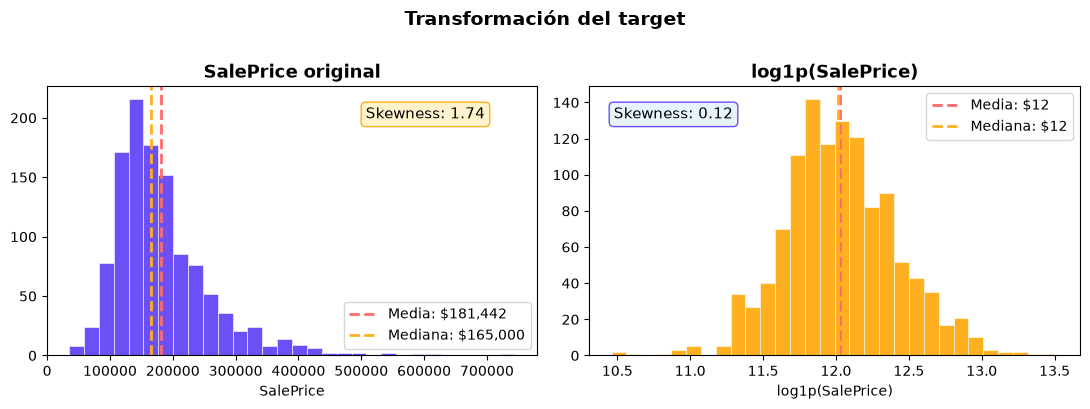

Skewness original: 1.743
Skewness log1p:    0.125


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4), facecolor='white')

VIOLET = '#6C4FF6'
AMBER  = '#FFB020'

axes[0].hist(y_train, bins=30, color=VIOLET, edgecolor='white', linewidth=0.4)
axes[0].set_title('SalePrice original', fontsize=13, fontweight='bold')
axes[0].set_xlabel('SalePrice')
skew_orig = y_train.skew()
axes[0].annotate(f'Skewness: {skew_orig:.2f}', xy=(0.65, 0.88),
                 xycoords='axes fraction', fontsize=11,
                 bbox=dict(boxstyle='round,pad=0.3', fc='#FFF3CD', ec=AMBER))
axes[0].axvline(y_train.mean(), color='#FF6B6B', linewidth=2,
           linestyle='--', label=f"Media: ${y_train.mean():,.0f}")
axes[0].axvline(y_train.median(), color='#FFB020', linewidth=2,
           linestyle='--', label=f"Mediana: ${y_train.median():,.0f}")

y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

axes[1].hist(y_train_log, bins=30, color=AMBER, edgecolor='white', linewidth=0.4)
axes[1].set_title('log1p(SalePrice)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log1p(SalePrice)')
skew_log = y_train_log.skew()
axes[1].annotate(f'Skewness: {skew_log:.2f}', xy=(0.05, 0.88),
                 xycoords='axes fraction', fontsize=11,
                 bbox=dict(boxstyle='round,pad=0.3', fc='#E8F4FD', ec=VIOLET))
axes[1].axvline(y_train_log.mean(), color='#FF6B6B', linewidth=2,
           linestyle='--', label=f"Media: ${y_train_log.mean():,.0f}")
axes[1].axvline(y_train_log.median(), color='#FFB020', linewidth=2,
           linestyle='--', label=f"Mediana: ${y_train_log.median():,.0f}")


fig.suptitle('Transformación del target', fontsize=14, fontweight='bold', y=1.01)
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

print(f'Skewness original: {skew_orig:.3f}')
print(f'Skewness log1p:    {skew_log:.3f}')

---
## Escalado de variables numéricas

Escalar no cambia la distribución, solo cambia la unidad de medida.

`SalePrice` tiene outliers; para las features numéricas preferimos `RobustScaler`.  
El scaler se calibra solo con train.

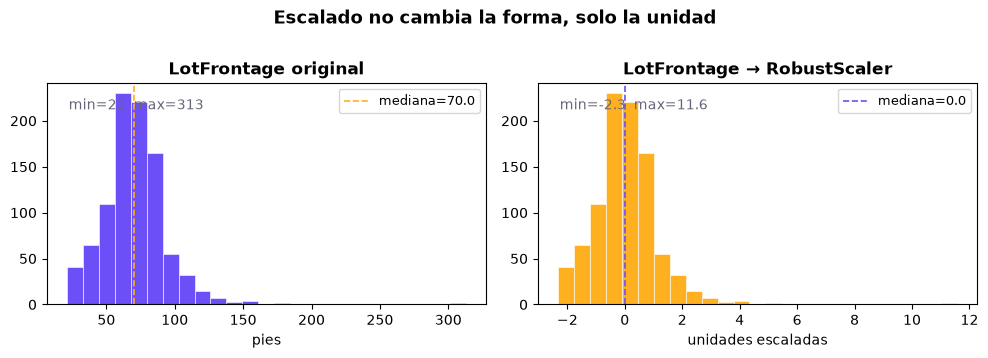

Mediana aprendida (del train): [70.]
IQR aprendido    (del train): [21.]


In [16]:
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import numpy as np

# Extraer LotFrontage de train (con nulos aún presentes)
lf = X_train['LotFrontage'].dropna().values

scaler = RobustScaler()
lf_scaled = scaler.fit_transform(lf.reshape(-1, 1)).ravel()

VIOLET, AMBER, MUTED = '#6C4FF6', '#FFB020', '#6B6478'

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), facecolor='white')

axes[0].hist(lf, bins=25, color=VIOLET, edgecolor='white', linewidth=0.4)
axes[0].set_title('LotFrontage original', fontsize=12, fontweight='bold')
axes[0].set_xlabel('pies')
axes[0].axvline(np.median(lf), color=AMBER, linestyle='--', linewidth=1.2,
                label=f'mediana={np.median(lf):.1f}')
axes[0].legend(fontsize=9)
axes[0].annotate(f'min={lf.min():.0f}  max={lf.max():.0f}',
                 xy=(0.05, 0.88), xycoords='axes fraction', fontsize=10,
                 color=MUTED)

axes[1].hist(lf_scaled, bins=25, color=AMBER, edgecolor='white', linewidth=0.4)
axes[1].set_title('LotFrontage → RobustScaler', fontsize=12, fontweight='bold')
axes[1].set_xlabel('unidades escaladas')
axes[1].axvline(np.median(lf_scaled), color=VIOLET, linestyle='--', linewidth=1.2,
                label=f'mediana={np.median(lf_scaled):.1f}')
axes[1].legend(fontsize=9)
axes[1].annotate(f'min={lf_scaled.min():.1f}  max={lf_scaled.max():.1f}',
                 xy=(0.05, 0.88), xycoords='axes fraction', fontsize=10,
                 color=MUTED)

fig.suptitle('Escalado no cambia la forma, solo la unidad', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Mediana aprendida (del train):', scaler.center_)
print('IQR aprendido    (del train):', scaler.scale_)

---
## 8. Codificación de variables categóricas

Las variables categóricas no pueden entrar crudas al modelo, necesitamos convertirlas a números.
La estrategia depende de si la variable tiene orden o no.

In [25]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# --- Ordinal: ExterQual ---
orden_calidad = ['Fa', 'TA', 'Gd', 'Ex']

enc_ord = OrdinalEncoder(
    categories=[orden_calidad],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

# fit
exterqual_train = enc_ord.fit_transform(X_train[['ExterQual']])
exterqual_test  = enc_ord.transform(X_test[['ExterQual']])

print('OrdinalEncoder — ExterQual:')
for cat, val in zip(orden_calidad, enc_ord.categories_[0]):
    print(f'  {val} → {orden_calidad.index(val)}')

# --- Nominal: Neighborhood ---
enc_nom = OneHotEncoder(
    sparse_output=False,
    handle_unknown='infrequent_if_exist',
    drop='first'
)

# fit
enc_nom.fit(X_train[['Neighborhood']])

print(f'\nOneHotEncoder — Neighborhood:')
print(f'  Categorías aprendidas en train: {enc_nom.categories_[0].tolist()}')
print(f'  Columnas generadas: {len(enc_nom.get_feature_names_out())} (k-1 = {len(enc_nom.categories_[0])-1})')

OrdinalEncoder — ExterQual:
  Fa → 0
  TA → 1
  Gd → 2
  Ex → 3

OneHotEncoder — Neighborhood:
  Categorías aprendidas en train: ['Blmngtn', 'Blueste', 'BrDale', 'BrkSide', 'ClearCr', 'CollgCr', 'Crawfor', 'Edwards', 'Gilbert', 'IDOTRR', 'MeadowV', 'Mitchel', 'NAmes', 'NPkVill', 'NWAmes', 'NoRidge', 'NridgHt', 'OldTown', 'SWISU', 'Sawyer', 'SawyerW', 'Somerst', 'StoneBr', 'Timber', 'Veenker']
  Columnas generadas: 24 (k-1 = 24)


---
## 7. Pipeline + ColumnTransformer

Definimos qué le pasa a cada grupo de columnas, y encadenamos todo en un solo objeto reproducible.

| Columna | Tipo | Tratamiento |
|---------|------|-------------|
| `LotFrontage` | Numérica con nulos reales | Imputar mediana global y luego StandardScaler |
| `GrLivArea` | Numérica continua | StandardScaler |
| `ExterQual`, `KitchenQual` | Ordinal | OrdinalEncoder (Ex>Gd>TA>Fa) |
| `Neighborhood`, `MSSubClass`, `PoolQC`, `GarageType` | Nominal | OneHotEncoder |


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler, OrdinalEncoder, OneHotEncoder
)

# --- Columnas por grupo ---
cols_num  = ['LotFrontage', 'GrLivArea']
cols_ord  = ['ExterQual', 'KitchenQual']
cols_nom  = ['Neighborhood', 'MSSubClass', 'PoolQC', 'GarageType']

# Orden de categorías para ordinales (de peor a mejor)
orden_calidad = [['Fa', 'TA', 'Gd', 'Ex']]

# --- Pipelines por tipo ---
num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   # paso 1: imputar
    ('scaler',  StandardScaler())                    # paso 2: escalar
])

ord_pipe = Pipeline(steps=[
    ('encoder', OrdinalEncoder(categories=orden_calidad * len(cols_ord),
                               handle_unknown='use_encoded_value',
                               unknown_value=-1))
])

nom_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # por si quedan nulos
    ('encoder', OneHotEncoder(handle_unknown='infrequent_if_exist', sparse_output=False, drop='first'))
])

# --- ColumnTransformer (ensambla todo) ---
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, cols_num),
    ('ord', ord_pipe, cols_ord),
    ('nom', nom_pipe, cols_nom),
], remainder='drop')  # columnas no listadas se descartan

print('Preprocessor definido.')
print('Transformaciones:')
print(f'  Numéricas  ({len(cols_num)}): {cols_num}')
print(f'  Ordinales  ({len(cols_ord)}): {cols_ord}')
print(f'  Nominales  ({len(cols_nom)}): {cols_nom}')

Preprocessor definido.
Transformaciones:
  Numéricas  (2): ['LotFrontage', 'GrLivArea']
  Ordinales  (2): ['ExterQual', 'KitchenQual']
  Nominales  (4): ['Neighborhood', 'MSSubClass', 'PoolQC', 'GarageType']


---
## `fit_transform` en train, `transform` en test

In [23]:
# fit_transform
X_train_proc = preprocessor.fit_transform(X_train)

# transform
X_test_proc  = preprocessor.transform(X_test)

print(f'X_train procesado: {X_train_proc.shape}')
print(f'X_test procesado:  {X_test_proc.shape}')
print()
print('Mediana aprendida para LotFrontage')
mediana_aprendida = preprocessor.named_transformers_['num']['imputer'].statistics_[0]
print(f'  Mediana = {mediana_aprendida:.1f} pies')

X_train procesado: (1168, 51)
X_test procesado:  (292, 51)

Mediana aprendida para LotFrontage
  Mediana = 70.0 pies


---
## 9. Verificación final

Antes de pasar al modelo, checamos 3 cosas: no quedan nulos, las dimensiones cuadran, y los valores están en escala razonable.

In [24]:
print('=== VERIFICACIÓN FINAL ===')
print()

# ¿Quedan nulos?
nulos_train = np.isnan(X_train_proc).sum()
nulos_test  = np.isnan(X_test_proc).sum()
print(f'Nulos en X_train_proc: {nulos_train}' if nulos_train == 0 else f'Nulos en train: {nulos_train}')
print(f'Nulos en X_test_proc:  {nulos_test}' if nulos_test  == 0 else f'Nulos en test: {nulos_test}')
print()

# Dimensiones
print(f'Filas train: {X_train_proc.shape[0]} | Features: {X_train_proc.shape[1]}')
print(f'Filas test:  {X_test_proc.shape[0]} | Features: {X_test_proc.shape[1]}')
print()

# Rango de valores (las columnas numéricas deben estar estandarizadas)
print(f'Min/Max X_train_proc: [{X_train_proc.min():.2f}, {X_train_proc.max():.2f}]')

# ¿Target transformado?
print()
print(f'y_train_log — min: {y_train_log.min():.2f}, max: {y_train_log.max():.2f}, media: {y_train_log.mean():.2f}')
print()
print('Pipeline listo')

=== VERIFICACIÓN FINAL ===

Nulos en X_train_proc: 0
Nulos en X_test_proc:  0

Filas train: 1168 | Features: 51
Filas test:  292 | Features: 51

Min/Max X_train_proc: [-2.28, 10.60]

y_train_log — min: 10.46, max: 13.52, media: 12.03

Pipeline listo
